In [28]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

S0 = 100
K  = 100
r = 0.03
sigma = 0.2
T = 1

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
    return price

V_BS = black_scholes_call(S0, K, r, sigma, T)

print(f"Black-Scholes benchmark: {V_BS:.4f}")

Black-Scholes benchmark: 9.4134


In [29]:
def generate_iid_variables(M):
    Z = np.random.normal(0, 1, M)
    return Z

def S_T(S0, r, sigma, T, Z):
    exponent = (r - 0.5*sigma**2) * T + sigma * np.sqrt(T)*Z
    return S0*np.exp(exponent)

def payoff_function(S, K):
    return np.maximum(S - K, 0)

def V_hat(payoff, M, r, T):
    return np.exp(-r * T) / M * np.sum(payoff)

def SE_hat(payoff, M, r, T):
    sample_std = np.std(payoff, ddof = 1)
    return np.exp(-r * T) * sample_std / np.sqrt(M)

Z = generate_iid_variables(M)

ST = S_T(S0, r, sigma, T, Z)



In [30]:

M_values = np.array([10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5, 5*10**5])
R = 100

RMSE = np.zeros(len(M_values))
empirical_coverages = np.zeros(len(M_values))
CI_upper = np.zeros(len(M_values))
CI_lower = np.zeros(len(M_values))
representative_V = np.zeros(len(M_values))

for i, M in enumerate(M_values):
    V_estimates = np.zeros(R)
    SE_estimates = np.zeros(R)
    CI_upper_estimates = np.zeros(R)
    CI_lower_estimates = np.zeros(R)
    covered = np.zeros(R)

    for j in range(R):
        Z = generate_iid_variables(M)

        ST = S_T(S0, r, sigma, T, Z)

        payoff = payoff_function(ST, K)

        V_estimates[j] = V_hat(payoff, M, r, T)
        SE_estimates[j] = SE_hat(payoff, M, r, T)
        CI_upper_estimates[j] = V_estimates[j] + 1.96 * SE_estimates[j]
        CI_lower_estimates[j] = V_estimates[j] - 1.96 * SE_estimates[j]
        if CI_lower_estimates[j] <= V_BS <= CI_upper_estimates[j]:
            covered[j] = 1
        else:
            covered[j] = 0
    RMSE[i] = np.sqrt(1/R * np.sum((V_estimates - V_BS)**2))
    empirical_coverages[i] = np.mean(covered)  
    CI_upper[i] = CI_upper_estimates[0]
    CI_lower[i] = CI_lower_estimates[0]
    representative_V[i] = V_estimates[0]


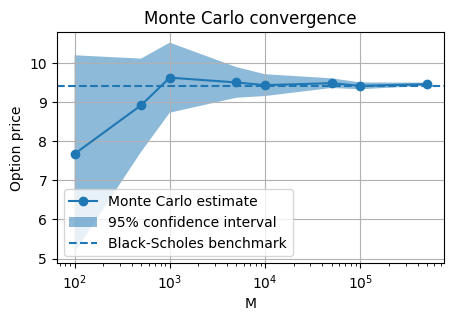

In [31]:
plt.figure(figsize=(5, 3))

plt.plot(M_values, representative_V, 'o-', label='Monte Carlo estimate')

plt.fill_between(
    M_values,
    CI_lower,
    CI_upper,
    alpha=0.5,
    label='95% confidence interval'
)

plt.axhline(V_BS, linestyle='--', label='Black-Scholes benchmark')
plt.xscale('log')
plt.xlabel('M')
plt.ylabel('Option price')
plt.title('Monte Carlo convergence')
plt.legend()
plt.grid()
plt.show()

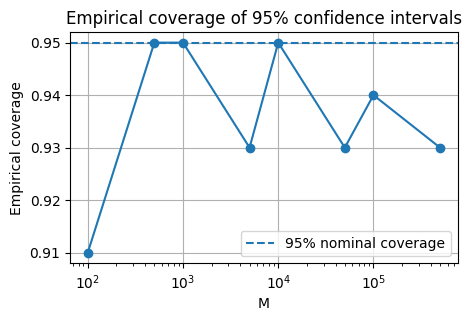

In [32]:
plt.figure(figsize=(5, 3))

plt.plot(M_values, empirical_coverages, 'o-')
plt.axhline(0.95, linestyle='--', label='95% nominal coverage')

plt.xscale('log')
plt.xlabel('M')
plt.ylabel('Empirical coverage')
plt.title('Empirical coverage of 95% confidence intervals')
plt.legend()
plt.grid()

plt.show()

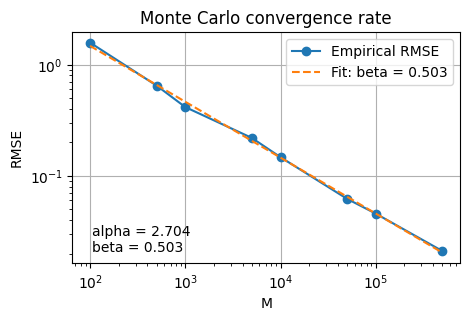

In [33]:
slope, intercept = np.polyfit(np.log(M_values), np.log(RMSE), 1)

beta = -slope
a = intercept

# Fitted RMSE values
RMSE_fit = np.exp(a) * M_values**(-beta)

plt.figure(figsize=(5, 3))

plt.loglog(M_values, RMSE, 'o-', label='Empirical RMSE')
plt.loglog(M_values, RMSE_fit, '--', label=f'Fit: beta = {beta:.3f}')

plt.xlabel('M')
plt.ylabel('RMSE')
plt.title('Monte Carlo convergence rate')

plt.text(0.05, 0.05, f'alpha = {a:.3f}\nbeta = {beta:.3f}', transform=plt.gca().transAxes)

plt.legend()
plt.grid()
plt.show()